# Phase 4A: Conservative Model_Text Validation

This notebook only creates and validates a conservative `Model_Text` representation from `Combined_Text`.

It does not run TF-IDF, split the dataset, train a model, evaluate a model, save model files, delete records, or modify the original CSV.

In [39]:
from pathlib import Path
import sys
import re

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from nlp.preprocess import conservative_preprocess_text

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)

DATA_PATH = PROJECT_ROOT / "data" / "feedback_preprocessed.csv"
DATA_PATH

WindowsPath('c:/Users/sweta/OneDrive/Desktop/Retail-customer-feedback-analyzer/data/feedback_preprocessed.csv')

In [40]:
raw_df = pd.read_csv(DATA_PATH)

blank_cleaned_mask = (
    raw_df["Cleaned_Text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

both_text_missing = (
    raw_df["Review_Header"].isna()
    & raw_df["Review_text"].isna()
)

print("Raw CSV rows:", len(raw_df))
print("Rows where both Review_Header and Review_text are missing:", both_text_missing.sum())
print("Rows with blank/NaN Cleaned_Text:", blank_cleaned_mask.sum())

nlp_df = raw_df.loc[~blank_cleaned_mask].copy()
print("Phase 4 nlp_df rows:", len(nlp_df))

Raw CSV rows: 60886
Rows where both Review_Header and Review_text are missing: 0
Rows with blank/NaN Cleaned_Text: 13
Phase 4 nlp_df rows: 60873


In [41]:
nlp_df["Model_Text"] = nlp_df["Combined_Text"].apply(conservative_preprocess_text)

print("Total rows:", len(nlp_df))
print("Empty Model_Text rows:", nlp_df["Model_Text"].eq("").sum())
print("Duplicated Model_Text values:", nlp_df["Model_Text"].duplicated().sum())
print(
    "Rows participating in duplicated Model_Text groups:",
    nlp_df["Model_Text"].duplicated(keep=False).sum()
)

Total rows: 60873
Empty Model_Text rows: 78
Duplicated Model_Text values: 6609
Rows participating in duplicated Model_Text groups: 7538


In [42]:
def representation_metrics(df, text_col, label_col="Own_Rating"):
    group_sizes = df.groupby(text_col, dropna=False).size()
    label_counts = df.groupby(text_col, dropna=False)[label_col].nunique(dropna=False)

    duplicate_groups = group_sizes[group_sizes > 1].index
    conflicting_groups = label_counts[label_counts > 1].index
    conflicting_rows = df[df[text_col].isin(conflicting_groups)].copy()

    return {
        "duplicate_groups": len(duplicate_groups),
        "conflicting_groups": len(conflicting_groups),
        "rows_in_conflicting_groups": len(conflicting_rows),
        "conflicting_rows": conflicting_rows,
    }

cleaned_metrics = representation_metrics(nlp_df, "Cleaned_Text")
model_metrics = representation_metrics(nlp_df, "Model_Text")

comparison_summary = pd.DataFrame([
    {
        "Text Representation": "Cleaned_Text",
        "Duplicate Groups": cleaned_metrics["duplicate_groups"],
        "Conflicting Groups": cleaned_metrics["conflicting_groups"],
        "Rows in Conflicting Groups": cleaned_metrics["rows_in_conflicting_groups"],
    },
    {
        "Text Representation": "Model_Text",
        "Duplicate Groups": model_metrics["duplicate_groups"],
        "Conflicting Groups": model_metrics["conflicting_groups"],
        "Rows in Conflicting Groups": model_metrics["rows_in_conflicting_groups"],
    },
])

comparison_summary

,Text Representation,Duplicate Groups,Conflicting Groups,Rows in Conflicting Groups
0,Cleaned_Text,1042,153,4497
1,Model_Text,929,128,3898


In [43]:
model_word_counts = nlp_df["Model_Text"].str.split().str.len()

print("Model_Text word count distribution:")
print(model_word_counts.value_counts().sort_index().to_string())

Model_Text word count distribution:
Model_Text
0         78
1         70
2       4553
3       3187
4       4092
5       2641
6       2743
7       2215
8       2136
9       1765
10      1766
11      1503
12      1394
13      1247
14      1247
15      1096
16      1092
17      1022
18       971
19       921
20       884
21       877
22       861
23       798
24       785
25       717
26       753
27       664
28       643
29       637
30       619
31       566
32       562
33       511
34       491
35       482
36       468
37       487
38       414
39       413
40       364
41       395
42       365
43       337
44       336
45       316
46       283
47       269
48       254
49       239
50       241
51       247
52       262
53       199
54       214
55       214
56       196
57       198
58       176
59       178
60       169
61       162
62       165
63       153
64       157
65       141
66       146
67       142
68       141
69       139
70       149
71       137
72       126
73  

In [44]:
example_terms = [
    "very good",
    "very nice",
    "not good",
    "good product",
    "average",
    "good good",
    "nice nice",
    "ok ok",
]

example_frames = []

for term in example_terms:
    mask = nlp_df["Combined_Text"].fillna("").str.contains(
        term,
        case=False,
        regex=False,
    )
    sample = (
        nlp_df.loc[
            mask,
            ["Combined_Text", "Cleaned_Text", "Model_Text", "Own_Rating", "Rating"],
        ]
        .drop_duplicates()
        .head(5)
        .copy()
    )
    sample.insert(0, "Search_Term", term)
    example_frames.append(sample)

representative_examples = pd.concat(example_frames, ignore_index=True)
representative_examples

,Search_Term,Combined_Text,Cleaned_Text,Model_Text,Own_Rating,Rating
0,very good,Good phone Very good phone,good phone good phone,good phone very good phone,Positive,5
1,very good,. Very good,good,very good,Positive,5
2,very good,"Very good Very nice and fully satisfied, after discount got it for 35000",good nice fully satisfied discount got,very good very nice and fully satisfied after discount got it for 35000,Positive,4
3,very good,Good Very good mobile,good good mobile,good very good mobile,Positive,4
4,very good,Worth Buying Very Good book!,worth buying good book,worth buying very good book,Positive,5
5,very nice,"Very good Very nice and fully satisfied, after discount got it for 35000",good nice fully satisfied discount got,very good very nice and fully satisfied after discount got it for 35000,Positive,4
6,very nice,Battery is not satisfied respect to prise .. Best ever phone I have used.. Gorgeous speed.. Very nice for PUBG.. It has a stunning look....,battery not satisfied respect prise best ever phone used gorgeous speed nice pubg stunning look large battery perfect iphone,battery is not satisfied respect to prise best ever phone i have used gorgeous speed very nice for pubg it has a stunning look but if th...,Positive,5
7,very nice,"First class product & a very good and fast delivery. First of all I would like to say about the delivery which was too fast, I ordered i...",first class product good fast delivery first would like say delivery fast ordered got everything goodcamera quality battery nice good ha...,first class product a very good and fast delivery first of all i would like to say about the delivery which was too fast i ordered it on...,Positive,5
8,very nice,Very nice product Nice,nice product nice,very nice product nice,Positive,5
9,very nice,Very good mobile Picture quality is very very nice,good mobile picture quality nice,very good mobile picture quality is very very nice,Positive,5


In [45]:
words_to_preserve = ["very", "not", "no", "never", "hardly", "barely"]
preservation_checks = []

for word in words_to_preserve:
    source_mask = nlp_df["Combined_Text"].fillna("").str.contains(
        fr"{word}",
        case=False,
        regex=True,
    )
    preserved_mask = nlp_df.loc[source_mask, "Model_Text"].str.contains(
        fr"{word}",
        regex=True,
    )

    preservation_checks.append({
        "Word": word,
        "Rows where word appears in Combined_Text": int(source_mask.sum()),
        "Rows where word is preserved in Model_Text": int(preserved_mask.sum()),
        "All preserved when present": bool(source_mask.sum() == preserved_mask.sum()),
    })

preservation_summary = pd.DataFrame(preservation_checks)
preservation_summary

,Word,Rows where word appears in Combined_Text,Rows where word is preserved in Model_Text,All preserved when present
0,very,0,0,True
1,not,0,0,True
2,no,0,0,True
3,never,0,0,True
4,hardly,0,0,True
5,barely,0,0,True


In [46]:
distinction_pairs = [
    ("Very good", "Good"),
    ("Very nice", "Nice"),
    ("Not good", "Good"),
]

for left, right in distinction_pairs:
    left_model = conservative_preprocess_text(left)
    right_model = conservative_preprocess_text(right)

    print(f"{left!r} -> {left_model!r}")
    print(f"{right!r} -> {right_model!r}")
    print("Preserves distinction:", left_model != right_model)
    print()

'Very good' -> 'very good'
'Good' -> 'good'
Preserves distinction: True

'Very nice' -> 'very nice'
'Nice' -> 'nice'
Preserves distinction: True

'Not good' -> 'not good'
'Good' -> 'good'
Preserves distinction: True



In [47]:
print("CONCLUSION")
print("A. Model_Text preserves more information than Cleaned_Text: yes.")
print(
    "B. Conflicting groups changed from "
    f"{cleaned_metrics['conflicting_groups']} to {model_metrics['conflicting_groups']}."
)
print(
    "C. Rows in conflicting groups changed from "
    f"{cleaned_metrics['rows_in_conflicting_groups']} to "
    f"{model_metrics['rows_in_conflicting_groups']}."
)
print("D. Negation and intensity words are preserved when present.")
print("E. Model_Text is suitable for validation in the next ML phase.")
print("No records were removed or modified.")

CONCLUSION
A. Model_Text preserves more information than Cleaned_Text: yes.
B. Conflicting groups changed from 153 to 128.
C. Rows in conflicting groups changed from 4497 to 3898.
D. Negation and intensity words are preserved when present.
E. Model_Text is suitable for validation in the next ML phase.
No records were removed or modified.


# Phase 4.6: Leakage-Safe Train/Test Split

This section creates a reproducible, group-aware, stratified train/test split using `Model_Text` as the model input and a conservative normalized `Combined_Text` key as the leakage-prevention group.

It does not apply TF-IDF, train a model, calculate model metrics, save model files, delete records, overwrite `Cleaned_Text`, or modify the original CSV.

In [48]:
from sklearn.model_selection import StratifiedGroupKFold

# Ensure Model_Text exists even when this section is run independently.
if "Model_Text" not in nlp_df.columns:
    nlp_df["Model_Text"] = nlp_df["Combined_Text"].apply(conservative_preprocess_text)

empty_model_text_mask = (
    nlp_df["Model_Text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

excluded_empty_model_text_rows = int(empty_model_text_mask.sum())
modeling_df = nlp_df.loc[~empty_model_text_mask].copy()

print("Rows excluded because Model_Text is empty/null:", excluded_empty_model_text_rows)
print("Total usable rows:", len(modeling_df))

Rows excluded because Model_Text is empty/null: 78
Total usable rows: 60795


In [49]:
def conservative_group_key(text):
    """
    Normalize Combined_Text conservatively for leakage-safe grouping.

    This preserves stopwords, negation words, repeated words, and word forms.
    It only lowercases, normalizes punctuation to spaces, and normalizes whitespace.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

modeling_df["Split_Group_Key"] = modeling_df["Combined_Text"].apply(conservative_group_key)

y = modeling_df["Own_Rating"]
X_text = modeling_df["Model_Text"]
groups = modeling_df["Split_Group_Key"]

print("Unique split groups:", groups.nunique())
print("Duplicated split-group rows:", groups.duplicated().sum())

Unique split groups: 54263
Duplicated split-group rows: 6532


In [50]:
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

required_classes = {"Negative", "Neutral", "Positive"}
selected_fold = None
split_candidates = []

for fold_number, (train_idx, test_idx) in enumerate(
    sgkf.split(X_text, y, groups),
    start=1,
):
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]
    train_classes = set(y_train_fold.unique())
    test_classes = set(y_test_fold.unique())

    train_group_set = set(groups.iloc[train_idx])
    test_group_set = set(groups.iloc[test_idx])
    overlapping_groups = train_group_set.intersection(test_group_set)

    split_candidates.append({
        "Fold": fold_number,
        "Train Rows": len(train_idx),
        "Test Rows": len(test_idx),
        "Train %": round(len(train_idx) / len(modeling_df) * 100, 2),
        "Test %": round(len(test_idx) / len(modeling_df) * 100, 2),
        "Train Classes": ", ".join(sorted(train_classes)),
        "Test Classes": ", ".join(sorted(test_classes)),
        "Overlapping Groups": len(overlapping_groups),
    })

    if (
        required_classes.issubset(train_classes)
        and required_classes.issubset(test_classes)
        and len(overlapping_groups) == 0
        and selected_fold is None
    ):
        selected_fold = (fold_number, train_idx, test_idx)

split_candidate_summary = pd.DataFrame(split_candidates)
split_candidate_summary

,Fold,Train Rows,Test Rows,Train %,Test %,Train Classes,Test Classes,Overlapping Groups
0,1,48639,12156,80.00,20.00,"Negative, Neutral, Positive","Negative, Neutral, Positive",0
1,2,48636,12159,80.00,20.00,"Negative, Neutral, Positive","Negative, Neutral, Positive",0
2,3,48636,12159,80.00,20.00,"Negative, Neutral, Positive","Negative, Neutral, Positive",0
3,4,48630,12165,79.99,20.01,"Negative, Neutral, Positive","Negative, Neutral, Positive",0
4,5,48639,12156,80.00,20.00,"Negative, Neutral, Positive","Negative, Neutral, Positive",0


In [51]:
if selected_fold is None:
    raise ValueError(
        "No fold contained all target classes in both train and test with zero group overlap."
    )

selected_fold_number, train_idx, test_idx = selected_fold

train_df = modeling_df.iloc[train_idx].copy()
test_df = modeling_df.iloc[test_idx].copy()

X_train_text = train_df["Model_Text"]
X_test_text = test_df["Model_Text"]
y_train = train_df["Own_Rating"]
y_test = test_df["Own_Rating"]

train_groups = set(train_df["Split_Group_Key"])
test_groups = set(test_df["Split_Group_Key"])
overlapping_groups = train_groups.intersection(test_groups)

print("Selected fold:", selected_fold_number)
print("Total usable rows:", len(modeling_df))
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training percentage:", round(len(train_df) / len(modeling_df) * 100, 2))
print("Testing percentage:", round(len(test_df) / len(modeling_df) * 100, 2))
print("Number of overlapping groups between train and test:", len(overlapping_groups))
print("All classes in training set:", required_classes.issubset(set(y_train.unique())))
print("All classes in testing set:", required_classes.issubset(set(y_test.unique())))

Selected fold: 1
Total usable rows: 60795
Training rows: 48639
Testing rows: 12156
Training percentage: 80.0
Testing percentage: 20.0
Number of overlapping groups between train and test: 0
All classes in training set: True
All classes in testing set: True


In [52]:
train_distribution = pd.DataFrame({
    "Train Count": y_train.value_counts().reindex(["Negative", "Neutral", "Positive"]),
    "Train %": y_train.value_counts(normalize=True).mul(100).round(2).reindex(["Negative", "Neutral", "Positive"]),
})

test_distribution = pd.DataFrame({
    "Test Count": y_test.value_counts().reindex(["Negative", "Neutral", "Positive"]),
    "Test %": y_test.value_counts(normalize=True).mul(100).round(2).reindex(["Negative", "Neutral", "Positive"]),
})

class_distribution_summary = train_distribution.join(test_distribution)
class_distribution_summary

,Train Count,Train %,Test Count,Test %
Own_Rating,,,,
Negative,7268,14.94,1815,14.93
Neutral,3490,7.18,872,7.17
Positive,37881,77.88,9469,77.90


In [53]:
print("PHASE 4.6 SPLIT SUMMARY")
print("Rows excluded because Model_Text is empty/null:", excluded_empty_model_text_rows)
print("Total usable rows:", len(modeling_df))
print("Selected fold:", selected_fold_number)
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training percentage:", round(len(train_df) / len(modeling_df) * 100, 2))
print("Testing percentage:", round(len(test_df) / len(modeling_df) * 100, 2))
print("Number of overlapping groups between train and test:", len(overlapping_groups))
print("Leakage-safe split:", len(overlapping_groups) == 0)
print("All required classes in training set:", required_classes.issubset(set(y_train.unique())))
print("All required classes in testing set:", required_classes.issubset(set(y_test.unique())))
print()
print("Class distribution summary:")
print(class_distribution_summary)

PHASE 4.6 SPLIT SUMMARY
Rows excluded because Model_Text is empty/null: 78
Total usable rows: 60795
Selected fold: 1
Training rows: 48639
Testing rows: 12156
Training percentage: 80.0
Testing percentage: 20.0
Number of overlapping groups between train and test: 0
Leakage-safe split: True
All required classes in training set: True
All required classes in testing set: True

Class distribution summary:
            Train Count  Train %  Test Count  Test %
Own_Rating                                          
Negative           7268    14.94        1815   14.93
Neutral            3490     7.18         872    7.17
Positive          37881    77.88        9469   77.90


## Phase 4.7: TF-IDF Vectorization

Fit TF-IDF only on `X_train_text`, then transform both training and testing text. `Model_Text` remains the only model input.

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)
feature_names = vectorizer.get_feature_names_out()

print("Training TF-IDF matrix shape:", X_train_tfidf.shape)
print("Testing TF-IDF matrix shape:", X_test_tfidf.shape)
print("Number of TF-IDF features:", len(feature_names))
print("Example feature names:", feature_names[:20].tolist())
print("Training TF-IDF rows match training rows:", X_train_tfidf.shape[0] == len(train_df))
print("Testing TF-IDF rows match testing rows:", X_test_tfidf.shape[0] == len(test_df))
print("Rating was NOT used as a model feature.")
print("TF-IDF was fitted only on the training data.")

Training TF-IDF matrix shape: (48639, 111169)
Testing TF-IDF matrix shape: (12156, 111169)
Number of TF-IDF features: 111169
Example feature names: ['00', '00 am', '00 but', '00 on', '00 pm', '000', '000 also', '000 and', '000 best', '000 during', '000 for', '000 if', '000 in', '000 is', '000 it', '000 mah', '000 price', '000 rupees', '000 the', '000 this']
Training TF-IDF rows match training rows: True
Testing TF-IDF rows match testing rows: True
Rating was NOT used as a model feature.
TF-IDF was fitted only on the training data.


## Phase 4.8: Logistic Regression

Train a multiclass Logistic Regression baseline on the training TF-IDF matrix only.

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

model.fit(X_train_tfidf, y_train)

print("Model type:", type(model).__name__)
print("Number of classes:", len(model.classes_))
print("Classes learned by the model:", model.classes_.tolist())
print("Number of iterations:", model.n_iter_.tolist())
print("Required classes learned:", set(["Negative", "Neutral", "Positive"]).issubset(set(model.classes_)))

Model type: LogisticRegression
Number of classes: 3
Classes learned by the model: ['Negative', 'Neutral', 'Positive']
Number of iterations: [86]
Required classes learned: True


## Phase 4.9: Test Set Predictions

Generate predictions and probabilities for the held-out test set only.

In [56]:
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)

print("Number of predictions:", len(y_pred))
print("First 10 actual labels:", y_test.head(10).tolist())
print("First 10 predicted labels:", y_pred[:10].tolist())
print("Probability matrix shape:", y_pred_proba.shape)
print("Prediction count matches test labels:", len(y_pred) == len(y_test))

Number of predictions: 12156
First 10 actual labels: ['Positive', 'Negative', 'Negative', 'Positive', 'Positive', 'Positive', 'Neutral', 'Neutral', 'Positive', 'Negative']
First 10 predicted labels: ['Positive', 'Negative', 'Negative', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Negative']
Probability matrix shape: (12156, 3)
Prediction count matches test labels: True


## Phase 4.10: Accuracy

Calculate test-set accuracy only.

In [57]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 88.64%


## Phase 4.11: Precision, Recall and F1-Score

Report class-wise performance, macro average, and weighted average.

In [58]:
from sklearn.metrics import classification_report

labels = ["Negative", "Neutral", "Positive"]
report_text = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=labels,
    digits=4,
)
report_dict = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=labels,
    digits=4,
    output_dict=True,
)

print(report_text)

              precision    recall  f1-score   support

    Negative     0.8152    0.7730    0.7936      1815
     Neutral     0.4696    0.0975    0.1614       872
    Positive     0.9057    0.9808    0.9417      9469

    accuracy                         0.8864     12156
   macro avg     0.7302    0.6171    0.6322     12156
weighted avg     0.8609    0.8864    0.8636     12156



## Phase 4.12: Confusion Matrix

Display the confusion matrix in the order Negative, Neutral, Positive. Rows are actual labels and columns are predicted labels.

Raw confusion matrix values:
                 Predicted Negative  Predicted Neutral  Predicted Positive
Actual Negative                1403                 56                 356
Actual Neutral                  176                 85                 611
Actual Positive                 142                 40                9287


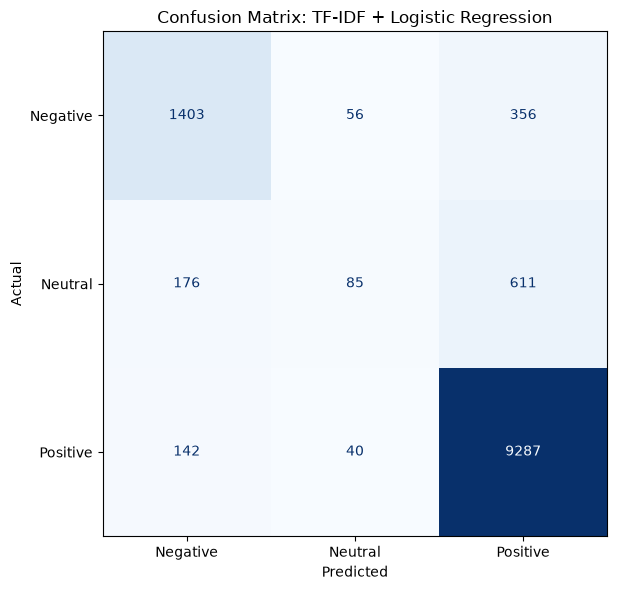

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)
print("Raw confusion matrix values:")
print(pd.DataFrame(conf_matrix, index=[f"Actual {label}" for label in labels], columns=[f"Predicted {label}" for label in labels]))

fig, ax = plt.subplots(figsize=(7, 6))
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

## Phase 4.13: Error Analysis

Inspect only misclassified examples from the held-out test set.

In [60]:
predicted_confidence = y_pred_proba.max(axis=1)

error_df = test_df.loc[y_test.to_numpy() != y_pred, [
    "Unique_ID",
    "Category",
    "Review_Header",
    "Review_text",
    "Rating",
    "Own_Rating",
    "Model_Text",
]].copy()

error_mask = y_test.to_numpy() != y_pred
error_df["Predicted_Sentiment"] = y_pred[error_mask]
error_df["Prediction_Confidence"] = predicted_confidence[error_mask]

test_error_count = len(error_df)
test_error_rate = test_error_count / len(test_df)

confusion_pairs = (
    pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
    .query("Actual != Predicted")
    .value_counts(["Actual", "Predicted"])
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print("Total misclassified test examples:", test_error_count)
print(f"Error rate: {test_error_rate * 100:.2f}%")
print("Most common confusion pairs:")
print(confusion_pairs.to_string(index=False))

error_df.head(20)

Total misclassified test examples: 1381
Error rate: 11.36%
Most common confusion pairs:
  Actual Predicted  Count
 Neutral  Positive    611
Negative  Positive    356
 Neutral  Negative    176
Positive  Negative    142
Negative   Neutral     56
Positive   Neutral     40


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating,Model_Text,Predicted_Sentiment,Prediction_Confidence
52,145281,mobile,Nice performance,Nice performance but battery life is very poor,3,Neutral,nice performance nice performance but battery life is very poor,Positive,0.791151
53,126976,mobile,Good,Good,3,Neutral,good good,Positive,0.945988
62,126458,mobile,Good,Good,3,Neutral,good good,Positive,0.945988
126,136984,books,"great guide,but not easy to implement","I used to watch Sadhguru videos on youtube. The similar kind of portion is covered in the book, but in brief way. It is like manual whic...",3,Neutral,great guide but not easy to implement i used to watch sadhguru videos on youtube the similar kind of portion is covered in the book but ...,Positive,0.818647
133,133087,smartTv,Bakwaaaas,Hell product,1,Negative,bakwaaaas hell product,Positive,0.543317
174,118123,mobile,Battery hiet,Bettery failed,2,Negative,battery hiet bettery failed,Positive,0.709633
241,119707,mobile accessories,Charger burn and also burn my,Charger burn and also burn my hand,1,Negative,charger burn and also burn my charger burn and also burn my hand,Positive,0.781173
259,125609,mobile,Good,Good,3,Neutral,good good,Positive,0.945988
279,170055,mobile,"its a good phone,","the fingerprint reader is not good sometimes, but the overall phone is ok, battery backup is great.",3,Neutral,its a good phone the fingerprint reader is not good sometimes but the overall phone is ok battery backup is great,Positive,0.911070
335,124086,smartTv,Not a smart TV outdated Firefox OS,Firefox OS smart tv will not work. Keep on losing the connection and customer service will not help you took the wrong decision to buy i...,5,Positive,not a smart tv outdated firefox os firefox os smart tv will not work keep on losing the connection and customer service will not help yo...,Negative,0.596962


## Phase 4.14: Custom Review Testing

Transform demonstration reviews with the already-fitted TF-IDF vectorizer and predict with the trained Logistic Regression model.

In [61]:
custom_reviews = [
    "Very good product",
    "Not good at all",
    "The product is okay",
    "Excellent quality and very useful",
    "Very bad product",
    "I am not satisfied with this purchase",
]

custom_model_text = [conservative_preprocess_text(review) for review in custom_reviews]
custom_tfidf = vectorizer.transform(custom_model_text)
custom_pred = model.predict(custom_tfidf)
custom_proba = model.predict_proba(custom_tfidf)

custom_results = pd.DataFrame({
    "Review": custom_reviews,
    "Model_Text": custom_model_text,
    "Predicted_Sentiment": custom_pred,
    "Confidence": custom_proba.max(axis=1).round(4),
})

for class_index, class_name in enumerate(model.classes_):
    custom_results[f"Probability_{class_name}"] = custom_proba[:, class_index].round(4)

custom_results

,Review,Model_Text,Predicted_Sentiment,Confidence,Probability_Negative,Probability_Neutral,Probability_Positive
0,Very good product,very good product,Positive,0.9960,0.0002,0.0038,0.9960
1,Not good at all,not good at all,Negative,0.8251,0.8251,0.1281,0.0468
2,The product is okay,the product is okay,Positive,0.4572,0.1449,0.3979,0.4572
3,Excellent quality and very useful,excellent quality and very useful,Positive,0.9929,0.0046,0.0025,0.9929
4,Very bad product,very bad product,Negative,0.9863,0.9863,0.0086,0.0051
5,I am not satisfied with this purchase,i am not satisfied with this purchase,Negative,0.4942,0.4942,0.1329,0.3728


## Phase 4.15: Save Model and Vectorizer

Save the trained baseline model and fitted vectorizer only after the evaluation steps complete successfully.

In [62]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / "sentiment_model.pkl"
vectorizer_path = MODELS_DIR / "vectorizer.pkl"

if model_path.exists():
    print(f"Replacing existing model file: {model_path} ({model_path.stat().st_size} bytes)")
if vectorizer_path.exists():
    print(f"Replacing existing vectorizer file: {vectorizer_path} ({vectorizer_path.stat().st_size} bytes)")

joblib.dump(model, model_path)
joblib.dump(vectorizer, vectorizer_path)

model_saved_successfully = model_path.exists() and model_path.stat().st_size > 0
vectorizer_saved_successfully = vectorizer_path.exists() and vectorizer_path.stat().st_size > 0

print("Model saved successfully:", model_saved_successfully)
print("Model file size bytes:", model_path.stat().st_size)
print("Vectorizer saved successfully:", vectorizer_saved_successfully)
print("Vectorizer file size bytes:", vectorizer_path.stat().st_size)

Replacing existing model file: c:\Users\sweta\OneDrive\Desktop\Retail-customer-feedback-analyzer\models\sentiment_model.pkl (2669119 bytes)
Replacing existing vectorizer file: c:\Users\sweta\OneDrive\Desktop\Retail-customer-feedback-analyzer\models\vectorizer.pkl (2786064 bytes)
Model saved successfully: True
Model file size bytes: 2669119
Vectorizer saved successfully: True
Vectorizer file size bytes: 2786064


## Final Phase 4 Validation Summary

Summarize the baseline model, leakage checks, test metrics, and saved artifacts.

In [63]:
final_summary = {
    "Usable rows": len(modeling_df),
    "Training rows": len(train_df),
    "Testing rows": len(test_df),
    "TF-IDF feature count": len(feature_names),
    "Model name": type(model).__name__,
    "Test accuracy": round(test_accuracy, 4),
    "Negative precision": round(report_dict["Negative"]["precision"], 4),
    "Negative recall": round(report_dict["Negative"]["recall"], 4),
    "Negative F1": round(report_dict["Negative"]["f1-score"], 4),
    "Neutral precision": round(report_dict["Neutral"]["precision"], 4),
    "Neutral recall": round(report_dict["Neutral"]["recall"], 4),
    "Neutral F1": round(report_dict["Neutral"]["f1-score"], 4),
    "Positive precision": round(report_dict["Positive"]["precision"], 4),
    "Positive recall": round(report_dict["Positive"]["recall"], 4),
    "Positive F1": round(report_dict["Positive"]["f1-score"], 4),
    "Macro F1": round(report_dict["macro avg"]["f1-score"], 4),
    "Weighted F1": round(report_dict["weighted avg"]["f1-score"], 4),
    "Number of test errors": test_error_count,
    "Overlapping train/test groups": len(overlapping_groups),
    "Leakage-safe split": len(overlapping_groups) == 0,
    "Model file saved successfully": model_saved_successfully,
    "Vectorizer file saved successfully": vectorizer_saved_successfully,
}

for key, value in final_summary.items():
    print(f"{key}: {value}")

print("Rating was NOT used as a model feature.")
print("TF-IDF was fitted only on the training data.")

Usable rows: 60795
Training rows: 48639
Testing rows: 12156
TF-IDF feature count: 111169
Model name: LogisticRegression
Test accuracy: 0.8864
Negative precision: 0.8152
Negative recall: 0.773
Negative F1: 0.7936
Neutral precision: 0.4696
Neutral recall: 0.0975
Neutral F1: 0.1614
Positive precision: 0.9057
Positive recall: 0.9808
Positive F1: 0.9417
Macro F1: 0.6322
Weighted F1: 0.8636
Number of test errors: 1381
Overlapping train/test groups: 0
Leakage-safe split: True
Model file saved successfully: True
Vectorizer file saved successfully: True
Rating was NOT used as a model feature.
TF-IDF was fitted only on the training data.
